In [29]:
# seoul_0719.csv 파일과 seoul_1926.csv 파일을 읽어 2026년 9월 22일 일자를 예측하기

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('font', family ='AppleGothic')
seoul1 = pd.read_csv("seoul_0719.csv", encoding="cp949")
seoul2 = pd.read_csv("seoul_1926.csv", encoding="cp949")
seoul1.info()
seoul2.info()

<class 'pandas.DataFrame'>
RangeIndex: 40221 entries, 0 to 40220
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   날짜       40221 non-null  str    
 1   지점       40221 non-null  int64  
 2   평균기온(℃)  39465 non-null  float64
 3   최저기온(℃)  39464 non-null  float64
 4   최고기온(℃)  39463 non-null  float64
dtypes: float64(3), int64(1), str(1)
memory usage: 1.5 MB
<class 'pandas.DataFrame'>
RangeIndex: 2820 entries, 0 to 2819
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   지점        2820 non-null   int64  
 1   지점명       2820 non-null   str    
 2   일시        2820 non-null   str    
 3   평균기온(°C)  2820 non-null   float64
 4   최저기온(°C)  2819 non-null   float64
 5   최고기온(°C)  2820 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 132.3 KB


In [30]:
del seoul1['지점']

In [31]:
seoul2 = seoul2.drop(['지점','지점명'], axis=1)
seoul1.info()
seoul2.info()

<class 'pandas.DataFrame'>
RangeIndex: 40221 entries, 0 to 40220
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   날짜       40221 non-null  str    
 1   평균기온(℃)  39465 non-null  float64
 2   최저기온(℃)  39464 non-null  float64
 3   최고기온(℃)  39463 non-null  float64
dtypes: float64(3), str(1)
memory usage: 1.2 MB
<class 'pandas.DataFrame'>
RangeIndex: 2820 entries, 0 to 2819
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   일시        2820 non-null   str    
 1   평균기온(°C)  2820 non-null   float64
 2   최저기온(°C)  2819 non-null   float64
 3   최고기온(°C)  2820 non-null   float64
dtypes: float64(3), str(1)
memory usage: 88.3 KB


In [32]:
cols = ['날짜','평균기온','최저기온','최고기온']
seoul1.columns = cols
seoul2.columns = cols

In [33]:
seoul = pd.concat([seoul1,seoul2],axis=0)
seoul.info()

<class 'pandas.DataFrame'>
Index: 43041 entries, 0 to 2819
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      43041 non-null  str    
 1   평균기온    42285 non-null  float64
 2   최저기온    42283 non-null  float64
 3   최고기온    42283 non-null  float64
dtypes: float64(3), str(1)
memory usage: 1.6 MB


In [34]:
seoul = seoul.drop_duplicates()

In [35]:
seoul.info()

<class 'pandas.DataFrame'>
Index: 43024 entries, 0 to 2819
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      43024 non-null  str    
 1   평균기온    42268 non-null  float64
 2   최저기온    42266 non-null  float64
 3   최고기온    42266 non-null  float64
dtypes: float64(3), str(1)
memory usage: 1.6 MB


In [36]:
seoul.head()

,날짜,평균기온,최저기온,최고기온
0,1907-10-01,13.5,7.9,20.7
1,1907-10-02,16.2,7.9,22.0
2,1907-10-03,16.2,13.1,21.3
3,1907-10-04,16.5,11.2,22.0
4,1907-10-05,17.6,10.9,25.4


In [37]:

seoul['년도'] = seoul['날짜'].apply(lambda x: x[:4])
seoul0922 = seoul[seoul['날짜'].apply(lambda x: x[5:])=='09-22']
seoul0922 = seoul0922.dropna(subset=["평균기온","최저기온","최고기온"],axis=0)
seoul0922.head()

,날짜,평균기온,최저기온,최고기온,년도
357,1908-09-22,15.6,10.7,21.8,1908
722,1909-09-22,21.2,16.6,26.8,1909
1087,1910-09-22,19.2,14.9,25.7,1910
1452,1911-09-22,18.9,13.0,26.0,1911
1818,1912-09-22,16.1,9.6,23.6,1912


In [38]:
seoul.info()

<class 'pandas.DataFrame'>
Index: 43024 entries, 0 to 2819
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      43024 non-null  str    
 1   평균기온    42268 non-null  float64
 2   최저기온    42266 non-null  float64
 3   최고기온    42266 non-null  float64
 4   년도      43024 non-null  str    
dtypes: float64(3), str(2)
memory usage: 2.0 MB


In [40]:
#최저기온이 결측값인 레코드 제거하기
seoul = seoul.dropna(subset=['평균기온','최저기온','최고기온'])
seoul.info()

<class 'pandas.DataFrame'>
Index: 42265 entries, 0 to 2819
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      42265 non-null  str    
 1   평균기온    42265 non-null  float64
 2   최저기온    42265 non-null  float64
 3   최고기온    42265 non-null  float64
 4   년도      42265 non-null  str    
dtypes: float64(3), str(2)
memory usage: 1.9 MB


In [41]:
seoul['년도'] =  seoul['년도'].astype(int)

In [42]:
seoul.info()

<class 'pandas.DataFrame'>
Index: 42265 entries, 0 to 2819
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      42265 non-null  str    
 1   평균기온    42265 non-null  float64
 2   최저기온    42265 non-null  float64
 3   최고기온    42265 non-null  float64
 4   년도      42265 non-null  int64  
dtypes: float64(3), int64(1), str(1)
memory usage: 1.9 MB


In [44]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X = seoul0922[["년도"]]
Y = seoul0922['평균기온']
model.fit(X, Y)
result = model.predict([[2026]])
print(result)

[20.61981205]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


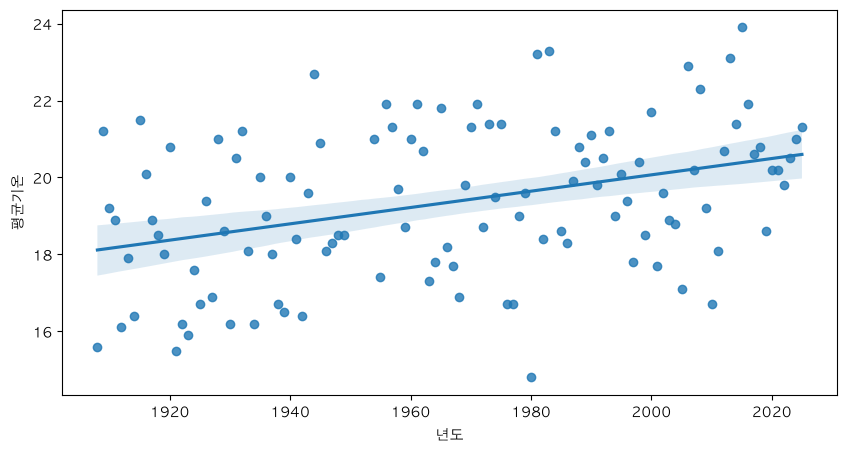

In [49]:
import seaborn as sns
#fx = np.linspace(1907, 2026, 120)
fig = plt.figure(figsize=(10, 5))   
ax1 = fig.add_subplot(1, 1, 1)
seoul0922['년도'] = pd.to_numeric(seoul0922['년도'], errors='coerce')
seoul0922['평균기온'] = pd.to_numeric(seoul0922['평균기온'], errors='coerce')
sns.regplot(x='년도', y='평균기온', data=seoul0922, ax=ax1) 
plt.show()


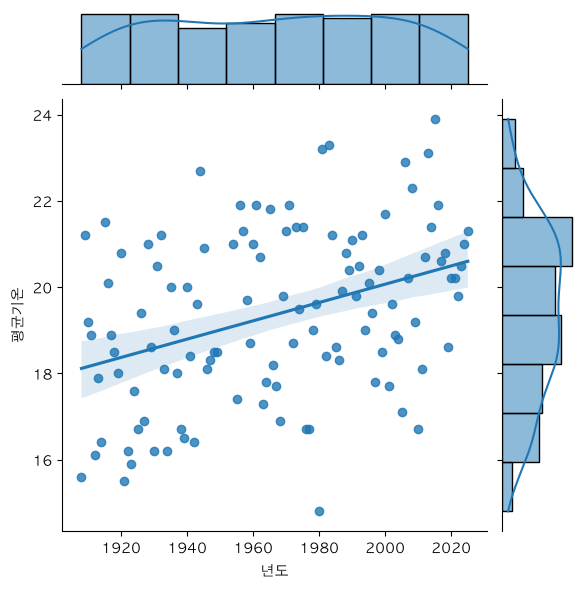

In [51]:

sns.jointplot(x='년도', y='평균기온', data=seoul0922, kind='reg')
plt.show()


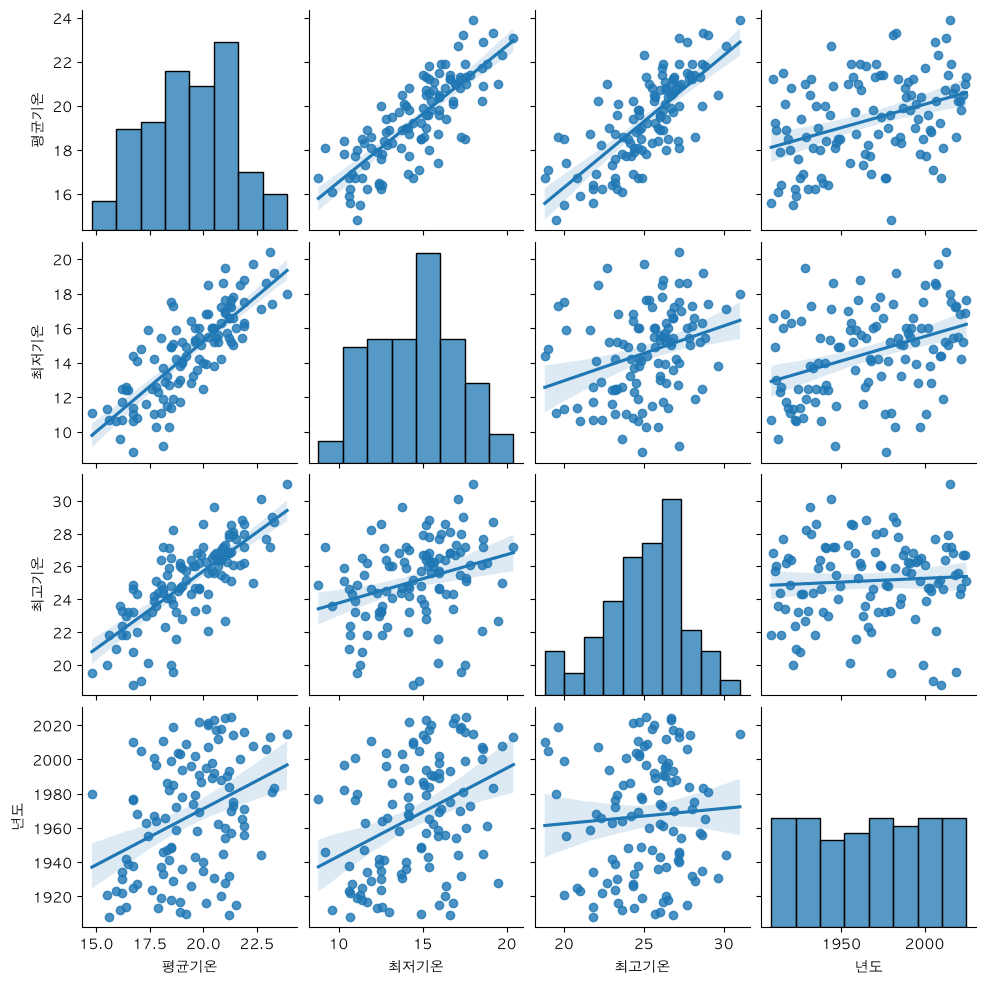

In [52]:

#seaborn pariplot 
sns.pairplot(seoul0922,kind='reg')